In [396]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score
)
from sklearn.model_selection import cross_validate
from data_profiling import ProfileReport
import warnings
warnings.filterwarnings('ignore')

from sklearn.decomposition import PCA



sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)


In [397]:
df = sns.load_dataset('titanic')

In [398]:
#profile = ProfileReport(df)
#profile.to_notebook_iframe()

- look at the data

In [399]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [400]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
survived,891.0,0.383838,0.486592,0.00,0.0000,0.0000,1.0,1.0000
pclass,891.0,2.308642,0.836071,1.00,2.0000,3.0000,3.0,3.0000
age,714.0,29.699118,14.526497,0.42,20.1250,28.0000,38.0,80.0000
sibsp,891.0,0.523008,1.102743,0.00,0.0000,0.0000,1.0,8.0000
parch,891.0,0.381594,0.806057,0.00,0.0000,0.0000,0.0,6.0000
fare,891.0,32.204208,49.693429,0.00,7.9104,14.4542,31.0,512.3292


In [401]:
df.describe(include='object')

,sex,embarked,who,embark_town,alive
count,891,889,891,889,891
unique,2,3,3,3,2
top,male,S,man,Southampton,no
freq,577,644,537,644,549


In [402]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [403]:
df.tail()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
886,0,2,male,27.0,0,0,13.00,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.00,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.45,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.00,C,First,man,True,C,Cherbourg,yes,True
890,0,3,male,32.0,0,0,7.75,Q,Third,man,True,NaN,Queenstown,no,True


- step 1 cleaning data

In [404]:
df.isnull().sum()/len(df)*100

survived        0.000000
pclass          0.000000
sex             0.000000
age            19.865320
sibsp           0.000000
parch           0.000000
fare            0.000000
embarked        0.224467
class           0.000000
who             0.000000
adult_male      0.000000
deck           77.216611
embark_town     0.224467
alive           0.000000
alone           0.000000
dtype: float64

- drop the deck column because the nulls persent is very heigh and drop alive column because its a copy of survived column and will make data leakage
and after looking at df i also found  embark_town and this coulmn is the same of embarked  column so i will dorp it all

In [405]:
df=df.drop([ 'deck' ,'alive','embark_town'],axis=1)


In [406]:
df.duplicated().sum()

111

In [407]:
df=df.drop_duplicates()

In [408]:
df.isnull().sum()/len(df)*100

survived       0.000000
pclass         0.000000
sex            0.000000
age           13.333333
sibsp          0.000000
parch          0.000000
fare           0.000000
embarked       0.256410
class          0.000000
who            0.000000
adult_male     0.000000
alone          0.000000
dtype: float64

In [409]:
df['age']=df['age'].fillna(df['age'].median())
df['embarked']=df['embarked'].fillna(df['embarked'].mode()[0])

In [410]:
df.isnull().sum()/len(df)*100


survived      0.0
pclass        0.0
sex           0.0
age           0.0
sibsp         0.0
parch         0.0
fare          0.0
embarked      0.0
class         0.0
who           0.0
adult_male    0.0
alone         0.0
dtype: float64

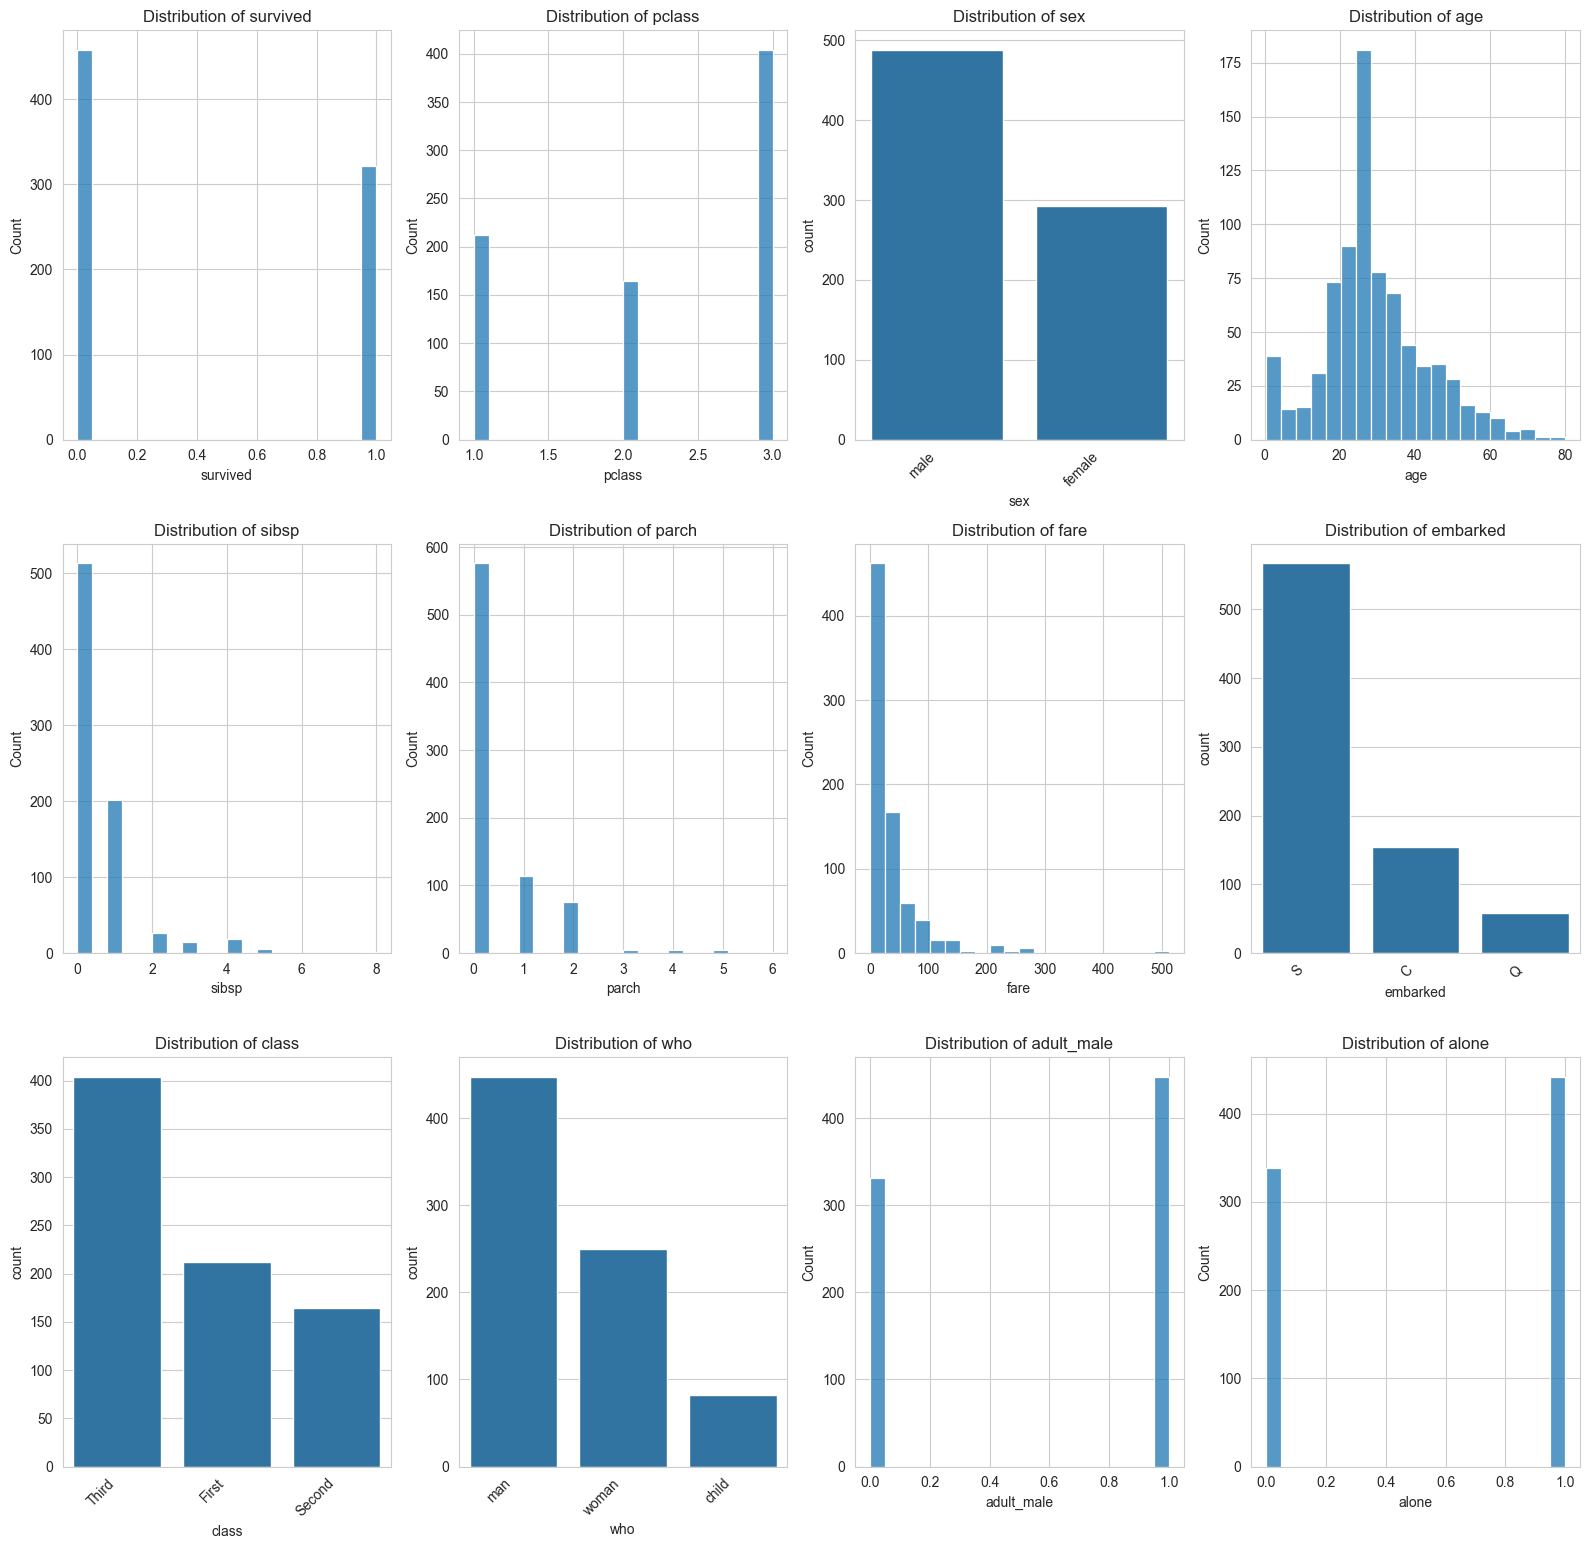

In [411]:
plt.figure(figsize=(16, 20))

for idx, col in enumerate(df.columns, start=1):
    plt.subplot(4, 4, idx)
    if pd.api.types.is_numeric_dtype(df[col]):
        sns.histplot(df[col], bins=20, kde=False)
        plt.xlabel(col)
    else:
        order = df[col].value_counts().index
        sns.countplot(data=df, x=col, order=order)
        plt.xticks(rotation=45, ha='right')
    plt.title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

- look at outlayers for age and fare

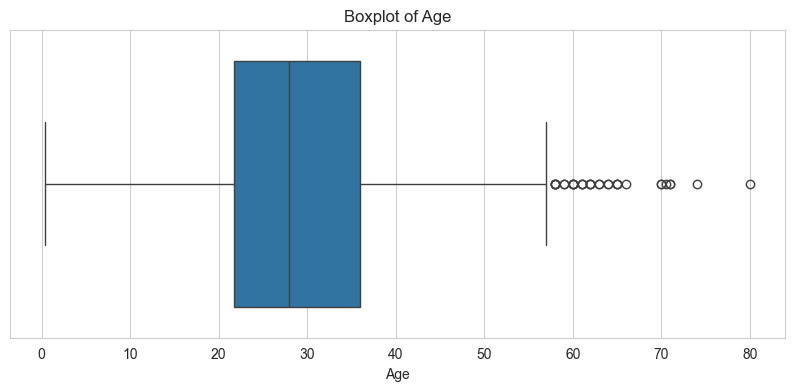

In [412]:
plt.figure(figsize=(10, 4))
sns.boxplot(x=df['age'])
plt.title('Boxplot of Age')
plt.xlabel('Age')
plt.show()

- the Distribution of age is normal and not need log 

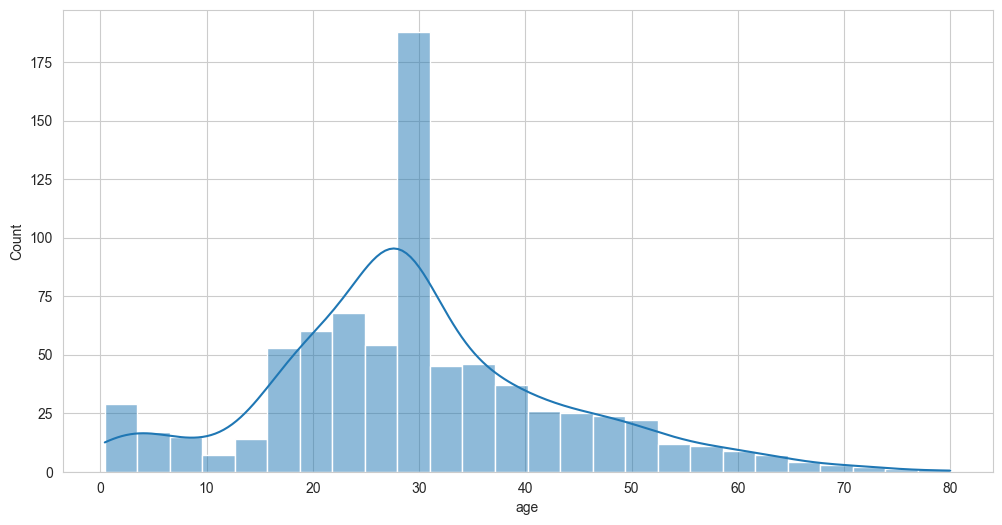

In [413]:

plt.figure(figsize=(12,6))
sns.histplot(df['age'], kde=True)
plt.show()

- look at outlayers of fare

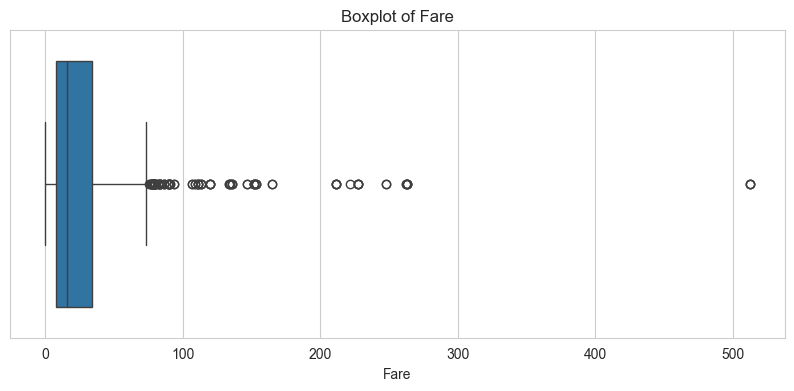

In [414]:
plt.figure(figsize=(10, 4))
sns.boxplot(x=df['fare'])
plt.title('Boxplot of Fare')
plt.xlabel('Fare')
plt.show()

In [415]:
df['fare'].unique()

array([  7.25  ,  71.2833,   7.925 ,  53.1   ,   8.05  ,   8.4583,
        51.8625,  21.075 ,  11.1333,  30.0708,  16.7   ,  26.55  ,
        31.275 ,   7.8542,  16.    ,  29.125 ,  13.    ,  18.    ,
         7.225 ,  26.    ,   8.0292,  35.5   ,  31.3875, 263.    ,
         7.8792,   7.8958,  27.7208, 146.5208,   7.75  ,  10.5   ,
        82.1708,  52.    ,   7.2292,  11.2417,   9.475 ,  21.    ,
        41.5792,  15.5   ,  21.6792,  17.8   ,  39.6875,   7.8   ,
        76.7292,  61.9792,  27.75  ,  46.9   ,  80.    ,  83.475 ,
        27.9   ,  15.2458,   8.1583,   8.6625,  73.5   ,  14.4542,
        56.4958,   7.65  ,  29.    ,  12.475 ,   9.    ,   9.5   ,
         7.7875,  47.1   ,  15.85  ,  34.375 ,  61.175 ,  20.575 ,
        34.6542,  63.3583,  23.    ,  77.2875,   8.6542,   7.775 ,
        24.15  ,   9.825 ,  14.4583, 247.5208,   7.1417,  22.3583,
         6.975 ,   7.05  ,  14.5   ,  15.0458,  26.2833,   9.2167,
        79.2   ,   6.75  ,  11.5   ,  36.75  ,   7.7958,  12.5

- The Fare column has a wide range of values and some values may appear unusual However this does not mean the data is wrong Ticket prices could vary factors such as family discounts infant tickets and different pricing for children adults and elderly passengers Therefore there is no strong reason to remove this column


<Axes: xlabel='pclass', ylabel='fare'>

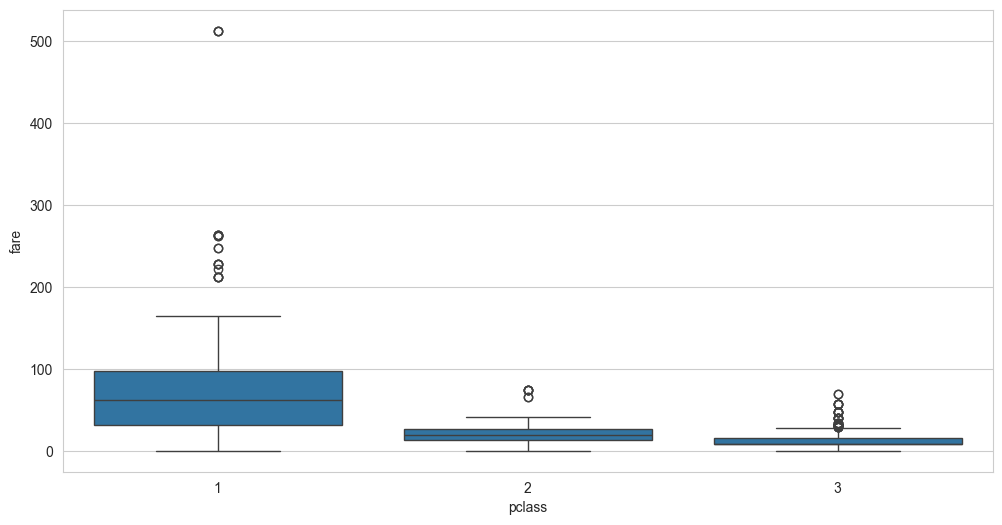

In [416]:
df.groupby('pclass')['fare'].describe()
sns.boxplot(x='pclass', y='fare', data=df)

- fare had a right skew and alot of outlayers so it need log  

In [417]:
df['fare'] = np.log1p(df['fare'])

In [418]:
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,alone
0,0,3,male,22.0,1,0,2.110213,S,Third,man,True,False
1,1,1,female,38.0,1,0,4.280593,C,First,woman,False,False
2,1,3,female,26.0,0,0,2.188856,S,Third,woman,False,True
3,1,1,female,35.0,1,0,3.990834,S,First,woman,False,False
4,0,3,male,35.0,0,0,2.202765,S,Third,man,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...
885,0,3,female,39.0,0,5,3.405355,Q,Third,woman,False,False
887,1,1,female,19.0,0,0,3.433987,S,First,woman,False,True
888,0,3,female,28.0,1,2,3.196630,S,Third,woman,False,False
889,1,1,male,26.0,0,0,3.433987,C,First,man,True,True


In [419]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
survived,780.0,0.412821,0.492657,0.00,0.000000,0.000000,1.000000,1.000000
pclass,780.0,2.246154,0.854452,1.00,1.000000,3.000000,3.000000,3.000000
age,780.0,29.571051,13.722689,0.42,21.750000,28.000000,36.000000,80.000000
sibsp,780.0,0.525641,0.988046,0.00,0.000000,0.000000,1.000000,8.000000
parch,780.0,0.417949,0.838536,0.00,0.000000,0.000000,1.000000,6.000000
fare,780.0,3.047227,0.961033,0.00,2.202765,2.830263,3.566005,6.240917


- feature Enginearing

In [420]:
df['family_size'] = df['sibsp'] + df['parch'] + 1

In [421]:
df['childWithParent'] = ((df['age'] < 16) & (df['parch'] > 0))

In [422]:
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,alone,family_size,childWithParent
0,0,3,male,22.0,1,0,2.110213,S,Third,man,True,False,2,False
1,1,1,female,38.0,1,0,4.280593,C,First,woman,False,False,2,False
2,1,3,female,26.0,0,0,2.188856,S,Third,woman,False,True,1,False
3,1,1,female,35.0,1,0,3.990834,S,First,woman,False,False,2,False
4,0,3,male,35.0,0,0,2.202765,S,Third,man,True,True,1,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
885,0,3,female,39.0,0,5,3.405355,Q,Third,woman,False,False,6,False
887,1,1,female,19.0,0,0,3.433987,S,First,woman,False,True,1,False
888,0,3,female,28.0,1,2,3.196630,S,Third,woman,False,False,4,False
889,1,1,male,26.0,0,0,3.433987,C,First,man,True,True,1,False


- encouding catigorical columns to be ready for corrloation and ML 

In [423]:
cat_cols = ['sex','embarked','who','alone','childWithParent','class','adult_male']
le = LabelEncoder()

for col in cat_cols:
  df[col] = le.fit_transform(df[col])

In [424]:
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,alone,family_size,childWithParent
0,0,3,1,22.0,1,0,2.110213,2,2,1,1,0,2,0
1,1,1,0,38.0,1,0,4.280593,0,0,2,0,0,2,0
2,1,3,0,26.0,0,0,2.188856,2,2,2,0,1,1,0
3,1,1,0,35.0,1,0,3.990834,2,0,2,0,0,2,0
4,0,3,1,35.0,0,0,2.202765,2,2,1,1,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
885,0,3,0,39.0,0,5,3.405355,1,2,2,0,0,6,0
887,1,1,0,19.0,0,0,3.433987,2,0,2,0,1,1,0
888,0,3,0,28.0,1,2,3.196630,2,2,2,0,0,4,0
889,1,1,1,26.0,0,0,3.433987,0,0,1,1,1,1,0


In [425]:
df.corr()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,alone,family_size,childWithParent
survived,1.000000,-0.336244,-0.513615,-0.077843,-0.037597,0.069669,0.312656,-0.155701,-0.336244,0.302949,-0.526358,-0.175864,0.013996,0.096772
pclass,-0.336244,1.000000,0.117507,-0.341238,0.086788,0.038975,-0.699381,0.178465,1.000000,-0.205654,0.069000,0.112711,0.077922,0.122781
sex,-0.513615,0.117507,1.000000,0.092817,-0.097959,-0.236962,-0.241395,0.099607,0.117507,-0.624203,0.898569,0.280483,-0.194416,-0.059130
age,-0.077843,-0.341238,0.092817,1.000000,-0.278655,-0.182174,0.107427,-0.025424,-0.341238,0.356608,0.273149,0.189145,-0.281656,-0.557095
sibsp,-0.037597,0.086788,-0.097959,-0.278655,1.000000,0.380596,0.290109,0.063675,0.086788,-0.196726,-0.274382,-0.608756,0.860061,0.449940
parch,0.069669,0.038975,-0.236962,-0.182174,0.380596,1.000000,0.302322,0.043387,0.038975,-0.067610,-0.347296,-0.570338,0.799131,0.395315
fare,0.312656,-0.699381,-0.241395,0.107427,0.290109,0.302322,1.000000,-0.219414,-0.699381,0.139371,-0.271173,-0.448205,0.355389,0.109002
embarked,-0.155701,0.178465,0.099607,-0.025424,0.063675,0.043387,-0.219414,1.000000,0.178465,-0.064045,0.081786,0.062846,0.065331,0.063726
class,-0.336244,1.000000,0.117507,-0.341238,0.086788,0.038975,-0.699381,0.178465,1.000000,-0.205654,0.069000,0.112711,0.077922,0.122781
who,0.302949,-0.205654,-0.624203,0.356608,-0.196726,-0.067610,0.139371,-0.064045,-0.205654,1.000000,-0.406276,0.028568,-0.165189,-0.624535


- i willnot remove columns now but i will use PCA algo for doing that

# *PCA*

- pca is unsupervised learner so i will drop target

In [426]:
X = df.drop('survived', axis=1)
y = df['survived']

In [427]:
X.corr()

,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,alone,family_size,childWithParent
pclass,1.000000,0.117507,-0.341238,0.086788,0.038975,-0.699381,0.178465,1.000000,-0.205654,0.069000,0.112711,0.077922,0.122781
sex,0.117507,1.000000,0.092817,-0.097959,-0.236962,-0.241395,0.099607,0.117507,-0.624203,0.898569,0.280483,-0.194416,-0.059130
age,-0.341238,0.092817,1.000000,-0.278655,-0.182174,0.107427,-0.025424,-0.341238,0.356608,0.273149,0.189145,-0.281656,-0.557095
sibsp,0.086788,-0.097959,-0.278655,1.000000,0.380596,0.290109,0.063675,0.086788,-0.196726,-0.274382,-0.608756,0.860061,0.449940
parch,0.038975,-0.236962,-0.182174,0.380596,1.000000,0.302322,0.043387,0.038975,-0.067610,-0.347296,-0.570338,0.799131,0.395315
fare,-0.699381,-0.241395,0.107427,0.290109,0.302322,1.000000,-0.219414,-0.699381,0.139371,-0.271173,-0.448205,0.355389,0.109002
embarked,0.178465,0.099607,-0.025424,0.063675,0.043387,-0.219414,1.000000,0.178465,-0.064045,0.081786,0.062846,0.065331,0.063726
class,1.000000,0.117507,-0.341238,0.086788,0.038975,-0.699381,0.178465,1.000000,-0.205654,0.069000,0.112711,0.077922,0.122781
who,-0.205654,-0.624203,0.356608,-0.196726,-0.067610,0.139371,-0.064045,-0.205654,1.000000,-0.406276,0.028568,-0.165189,-0.624535
adult_male,0.069000,0.898569,0.273149,-0.274382,-0.347296,-0.271173,0.081786,0.069000,-0.406276,1.000000,0.387910,-0.369979,-0.367600


- befor pca we need standardization 

In [428]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

- show variance to know number of components we need 

In [429]:
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

In [430]:
pca.explained_variance_ratio_

array([3.12615724e-01, 2.42076540e-01, 1.50494482e-01, 8.94896417e-02,
       7.03873311e-02, 4.74468829e-02, 3.35300287e-02, 2.69187632e-02,
       1.76126199e-02, 6.41258470e-03, 3.01540119e-03, 2.13378660e-17,
       0.00000000e+00])

In [431]:
cumulative = np.cumsum(pca.explained_variance_ratio_)
cumulative

array([0.31261572, 0.55469226, 0.70518675, 0.79467639, 0.86506372,
       0.9125106 , 0.94604063, 0.97295939, 0.99057201, 0.9969846 ,
       1.        , 1.        , 1.        ])

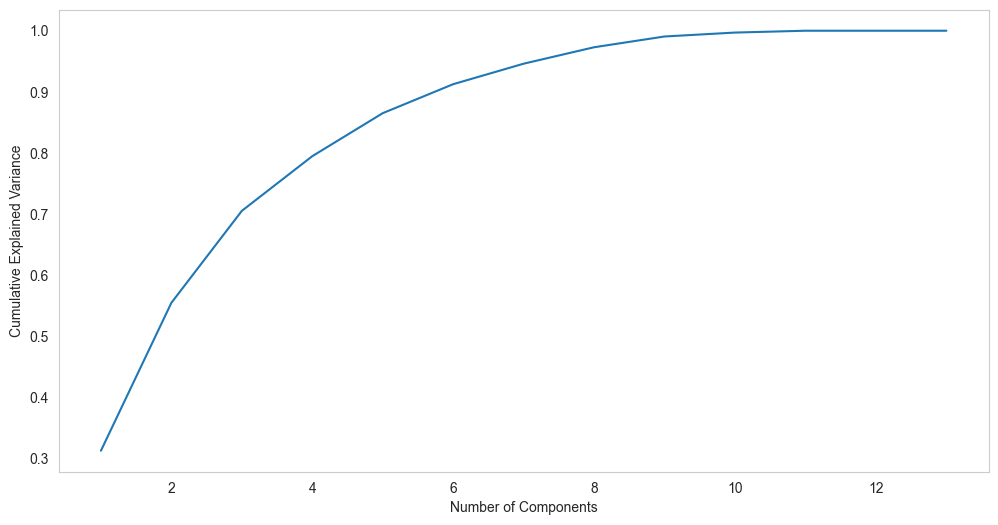

In [432]:
plt.plot(range(1, len(cumulative)+1), cumulative)
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid()
plt.show()

In [433]:
pca = PCA(n_components=6)
X_pca = pca.fit_transform(X_scaled)

X_pca

array([[-0.26057343,  1.81795537,  0.20135683,  0.796793  , -0.22677563,
        -0.83611946],
       [ 1.28653724, -3.4010019 , -0.41054373, -0.7176609 , -1.21054094,
        -0.83933853],
       [-0.73970686,  0.27235567, -2.82753942, -0.22597858,  0.63904971,
        -0.15496356],
       ...,
       [ 2.4405522 ,  0.12255853, -2.07892001,  1.58866745, -0.14853647,
         0.7345536 ],
       [-1.27183236, -1.53437575,  1.72677903, -1.5122299 , -1.04823722,
         0.09342142],
       [-1.85752043,  1.30433298, -0.02010495, -0.13426834, -0.91379887,
         0.1597538 ]])

# . ML

In [444]:
knn = KNeighborsClassifier(n_neighbors=5)

knn_scores = cross_validate(
    knn,
    X_pca,
    y,
    cv=5,
    scoring=['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
)

knn_scores

{'fit_time': array([0.00402665, 0.00309682, 0.        , 0.        , 0.00255489]),
 'score_time': array([0.0249002 , 0.0213623 , 0.02116084, 0.02266908, 0.01979852]),
 'test_accuracy': array([0.76923077, 0.72435897, 0.79487179, 0.82051282, 0.80769231]),
 'test_precision': array([0.78      , 0.68421053, 0.75      , 0.89361702, 0.76119403]),
 'test_recall': array([0.609375  , 0.609375  , 0.75      , 0.64615385, 0.78461538]),
 'test_f1': array([0.68421053, 0.6446281 , 0.75      , 0.75      , 0.77272727]),
 'test_roc_auc': array([0.81793478, 0.78710938, 0.85130774, 0.83000845, 0.87675402])}

In [438]:
log_model = LogisticRegression(max_iter=1000)

log_scores = cross_validate(
    log_model,
    X_pca,
    y,
    cv=5,
    scoring=['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
)
log_scores

{'fit_time': array([0.00812387, 0.01413131, 0.01733899, 0.01967406, 0.01453924]),
 'score_time': array([0.03280354, 0.04167175, 0.04332399, 0.07300448, 0.02951789]),
 'test_accuracy': array([0.77564103, 0.80128205, 0.76282051, 0.76282051, 0.83974359]),
 'test_precision': array([0.71641791, 0.77966102, 0.71428571, 0.75925926, 0.8125    ]),
 'test_recall': array([0.75      , 0.71875   , 0.703125  , 0.63076923, 0.8       ]),
 'test_f1': array([0.73282443, 0.74796748, 0.70866142, 0.68907563, 0.80620155]),
 'test_roc_auc': array([0.8372962 , 0.83933424, 0.84256114, 0.84142012, 0.90042265])}

In [439]:
tree_model = DecisionTreeClassifier(random_state=42)

tree_scores = cross_validate(
    tree_model,
    X_pca,
    y,
    cv=5,
    scoring=['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
)
tree_scores

{'fit_time': array([0.0123086 , 0.01733494, 0.0178721 , 0.01125646, 0.00816846]),
 'score_time': array([0.04044676, 0.0383935 , 0.03308439, 0.02210283, 0.02785587]),
 'test_accuracy': array([0.6474359 , 0.72435897, 0.73076923, 0.73076923, 0.76923077]),
 'test_precision': array([0.56923077, 0.67213115, 0.65714286, 0.69491525, 0.71014493]),
 'test_recall': array([0.578125  , 0.640625  , 0.71875   , 0.63076923, 0.75384615]),
 'test_f1': array([0.57364341, 0.656     , 0.68656716, 0.66129032, 0.73134328]),
 'test_roc_auc': array([0.63459579, 0.71076766, 0.72588315, 0.71859679, 0.7602705 ])}

In [440]:
rf_model = RandomForestClassifier(random_state=42)

rf_scores = cross_validate(
    rf_model,
    X_pca,
    y,
    cv=5,
    scoring=['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
)
rf_scores

{'fit_time': array([0.83067989, 0.44164395, 0.4064641 , 0.42198873, 0.37581682]),
 'score_time': array([0.06454968, 0.04636192, 0.08021092, 0.07599807, 0.08206868]),
 'test_accuracy': array([0.69230769, 0.75      , 0.75      , 0.75641026, 0.77564103]),
 'test_precision': array([0.62903226, 0.71186441, 0.6984127 , 0.74545455, 0.72058824]),
 'test_recall': array([0.609375  , 0.65625   , 0.6875    , 0.63076923, 0.75384615]),
 'test_f1': array([0.61904762, 0.68292683, 0.69291339, 0.68333333, 0.73684211]),
 'test_roc_auc': array([0.75016984, 0.78532609, 0.79738451, 0.77235841, 0.88148774])}

In [ ]:
scores = {
    'KNN': knn_scores['test_accuracy'],
    'Logistic Regression': log_scores['test_accuracy'],
    'Decision Tree': tree_scores['test_accuracy'],
    'Random Forest': rf_scores['test_accuracy']
}

scores_df = pd.DataFrame(scores)

best_accuracy = scores_df.max().sort_values(ascending=False)
mean_accuracy = scores_df.mean().loc[best_accuracy.index]

comparison = pd.DataFrame({
    'mean_accuracy': mean_accuracy,
    'best_accuracy': best_accuracy
})

print("Comparison of model accuracies:")
print(comparison)

plt.figure(figsize=(10, 6))
sns.barplot(x=comparison.index, y='best_accuracy', data=comparison, palette='coolwarm')
for idx, value in enumerate(comparison['best_accuracy']):
    plt.text(idx, value + 0.005, f"{value:.3f}", ha='center')
plt.ylim(0.65, 1.0)
plt.ylabel('Best CV Accuracy')
plt.title('Best Cross-Validated Accuracy per Model')
plt.show()

plt.figure(figsize=(10, 6))
sns.barplot(x=comparison.index, y='mean_accuracy', data=comparison, palette='viridis')
for idx, value in enumerate(comparison['mean_accuracy']):
    plt.text(idx, value + 0.005, f"{value:.3f}", ha='center')
plt.ylim(0.65, 1.0)
plt.ylabel('Mean CV Accuracy')
plt.title('Mean Cross-Validated Accuracy per Model')
plt.show()

- try knn without pca and cv

In [447]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [448]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [449]:
y_pred = knn.predict(X_test)
accuracy_score(y_test, y_pred)

0.7884615384615384

In [450]:
train_accuracy = accuracy_score(y_train, knn.predict(X_train))
test_accuracy = accuracy_score(y_test, knn.predict(X_test))

In [452]:
train_accuracy


0.8301282051282052

In [453]:
test_accuracy

0.7884615384615384